In [44]:
from typing import TypedDict , Annotated,Literal

from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage,HumanMessage
from sympy.core.facts import rules_2prereq


In [45]:
from dotenv import load_dotenv
load_dotenv()

True

In [46]:
import os
generator_llm=ChatGroq(model="llama-3.3-70b-versatile",api_key=os.getenv("API_KEY"))
evaluator_llm=ChatGroq(model="llama-3.3-70b-versatile",api_key=os.getenv("API_KEY"))
optimizer_llm=ChatGroq(model="llama-3.1-8b-instant",api_key=os.getenv("API_KEY"))

In [47]:
from groq import Groq
import os

client = Groq(api_key=os.getenv("API_KEY"))
models = client.models.list()

for m in models.data:
    print(m.id)

openai/gpt-oss-safeguard-20b
openai/gpt-oss-20b
meta-llama/llama-prompt-guard-2-22m
llama-3.1-8b-instant
canopylabs/orpheus-arabic-saudi
qwen/qwen3.6-27b
whisper-large-v3-turbo
whisper-large-v3
canopylabs/orpheus-v1-english
allam-2-7b
groq/compound
groq/compound-mini
meta-llama/llama-prompt-guard-2-86m
openai/gpt-oss-120b
llama-3.3-70b-versatile


In [48]:
class tweetstate(TypedDict):
    feedback:str
    topic:str
    iteration:int
    max_iteration:int
    tweet:str
    evaluation:Literal['approved',"needs_improvement"]

In [49]:
def generate_tweet(state: tweetstate):
     messages=[
         SystemMessage(content="you are a funny clever twitter influencer."),
         HumanMessage(content=f"""write a short , original humorous tweet in the topic{state['topic']} "
            rules:
            do not use question answer format
            maximum 200 character
            use observational humour , sarcasm
            think in meme logic
            use simple daya to day english
            this is the version {state['iteration']}""")]
     #llm generate#
     tweet=generator_llm.invoke(messages)
     return {'tweet':tweet}



In [50]:
class structure(BaseModel):
    evaluation:Literal['approved','needs_improvement']
    feedback:str

In [51]:
structured_evaluator_llm = evaluator_llm.with_structured_output(structure)

In [52]:
def evaluate_tweet(state: tweetstate):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?
2. Humor – Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness – Is it short, sharp, and scroll-stopping?
4. Virality Potential – Would people retweet or share it?
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [53]:
def optimize_tweet(state: tweetstate):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
dont mention anything like here is your revised tweet not mention anything as it is done by llm
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration }

In [54]:
def route_evaluation(state: tweetstate):
    if state["evaluation"] == 'approved' or state['iteration'] >=state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [55]:
graph = StateGraph(tweetstate)


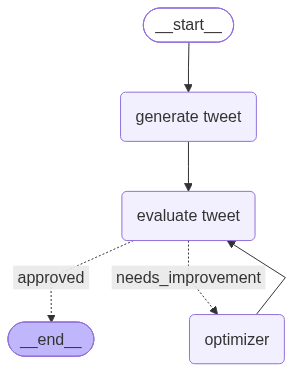

In [56]:
graph.add_node('generate tweet',generate_tweet)
graph.add_node('evaluate tweet',evaluate_tweet)
graph.add_node('optimizer',optimize_tweet)
graph.add_edge(START,"generate tweet")
graph.add_edge("generate tweet","evaluate tweet")
graph.add_conditional_edges(
    "evaluate tweet",
     route_evaluation,
    {
        'approved': END,
        'needs_improvement': 'optimizer'
    }
)
graph.add_edge('optimizer','evaluate tweet')
graph.compile()

In [57]:
topic = "india"

In [58]:
initial_state ={
    'topic':topic,
    'iteration':0,
    'max_iteration':5
}

In [59]:
workflow=graph.compile()

In [60]:
tweet = workflow.invoke(initial_state)

In [61]:
print(tweet['tweet'])

"When traffic lights turn green, it's not a suggestion, it's a warning: 'Clear the road, or else you'll be in a jam...with the police' #IndiaLife"
